# 00 — Preprocessing (CIC-IDS2017)

Run this notebook **once, first**. It loads, cleans, explores, and
preprocesses the data, then saves everything to `processed_data/` so
that the 6 individual model notebooks (`01`–`06`) and the comparison
notebook (`07`) all train and evaluate on the *exact same* data — which
is what makes the 6 results directly comparable.

> **Before running**: place all CIC-IDS2017 CSVs in the folder set by
> `DATA_DIR` below.

## Install & Import

In [1]:
# !pip install -q pandas numpy scikit-learn imbalanced-learn matplotlib seaborn joblib
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

from utils import PROCESSED_DIR, PLOTS_DIR
print("Setup complete.")


Setup complete.


## Load Dataset

In [2]:
DATA_DIR = "Data"  # <-- your CIC-IDS2017 CSV folder

# If you keep running out of memory, set this below 1.0 (e.g. 0.3 = use 30% of each file)
SAMPLE_FRAC = 0.1

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
assert len(csv_files) > 0, f"No CSV files found in '{DATA_DIR}'."
print(f"Found {len(csv_files)} CSV file(s):", *csv_files, sep="\n - ")

df_list = []
for f in csv_files:
    part = pd.read_csv(f)  # removed low_memory=False -- it actually uses MORE memory
    # downcast numeric columns to float32/int32 to roughly halve memory usage
    for col in part.select_dtypes(include=["float64"]).columns:
        part[col] = part[col].astype("float32")
    for col in part.select_dtypes(include=["int64"]).columns:
        part[col] = part[col].astype("int32")
    if SAMPLE_FRAC < 1.0:
        part = part.sample(frac=SAMPLE_FRAC, random_state=42)
    df_list.append(part)
    print(f"Loaded {f} -> {part.shape}")

df = pd.concat(df_list, axis=0, ignore_index=True)
del df_list
print(f"\nMerged shape: {df.shape}")


Found 8 CSV file(s):
 - Data\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Data\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Data\Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Data\Monday-WorkingHours.pcap_ISCX.csv
 - Data\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Data\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Data\Tuesday-WorkingHours.pcap_ISCX.csv
 - Data\Wednesday-workingHours.pcap_ISCX.csv
Loaded Data\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> (22574, 79)
Loaded Data\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> (28647, 79)
Loaded Data\Friday-WorkingHours-Morning.pcap_ISCX.csv -> (19103, 79)
Loaded Data\Monday-WorkingHours.pcap_ISCX.csv -> (52992, 79)
Loaded Data\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> (28860, 79)
Loaded Data\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> (17037, 79)
Loaded Data\Tuesday-WorkingHours.pcap_ISCX.csv -> (44591, 79)
Loaded Data\Wednesday-workingHour

## Dataset Overview

In [3]:
print(df.shape)
display(df.head())


(283074, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,9392887,4,0,24,0,6,6,6.000000,0.000000,...,20,1.982000e+03,0.0000,1982,1982,9390905.0,0.000000,9390905,9390905,DDoS
1,64007,5438011,1,5,6,30,6,6,6.000000,0.000000,...,20,2.715100e+04,0.0000,27151,27151,5410860.0,0.000000,5410860,5410860,BENIGN
2,80,115615609,20,15,1728,3463,578,0,86.400002,211.017929,...,32,1.609163e+05,134508.6875,566475,120118,10100000.0,46752.484375,10100000,9988018,BENIGN
3,80,9827,3,5,26,11601,20,0,8.666667,10.263203,...,20,0.000000e+00,0.0000,0,0,0.0,0.000000,0,0,DDoS
4,53315,87583370,7,9,11607,62,4380,0,1658.142822,1762.272827,...,20,4.219842e+06,0.0000,4219842,4219842,82600000.0,0.000000,82600000,82600000,BENIGN


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 283074 entries, 0 to 283073
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             283074 non-null  int32  
 1    Flow Duration                283074 non-null  int32  
 2    Total Fwd Packets            283074 non-null  int32  
 3    Total Backward Packets       283074 non-null  int32  
 4   Total Length of Fwd Packets   283074 non-null  int32  
 5    Total Length of Bwd Packets  283074 non-null  int32  
 6    Fwd Packet Length Max        283074 non-null  int32  
 7    Fwd Packet Length Min        283074 non-null  int32  
 8    Fwd Packet Length Mean       283074 non-null  float32
 9    Fwd Packet Length Std        283074 non-null  float32
 10  Bwd Packet Length Max         283074 non-null  int32  
 11   Bwd Packet Length Min        283074 non-null  int32  
 12   Bwd Packet Length Mean       283074 non-null  float32


## Data Cleaning

In [5]:
df.columns = df.columns.str.strip()
LABEL_COL = "Label"
assert LABEL_COL in df.columns

before = df.shape[0]
df = df.drop_duplicates()
print(f"Removed {before - df.shape[0]} duplicate rows.")

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum().sum()
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
print(f"Replaced {inf_count} inf values with NaN.")

before = df.shape[0]
df = df.dropna()
print(f"Dropped {before - df.shape[0]} rows with NaN.")
print(f"Final cleaned shape: {df.shape}")


Removed 14994 duplicate rows.
Replaced 309 inf values with NaN.
Dropped 173 rows with NaN.
Final cleaned shape: (267907, 79)


## EDA

Label
BENIGN                        219151
DoS Hulk                       17744
PortScan                       14529
DDoS                           12917
DoS GoldenEye                   1002
FTP-Patator                      651
DoS slowloris                    545
DoS Slowhttptest                 532
SSH-Patator                      415
Bot                              180
Web Attack � Brute Force         166
Web Attack � XSS                  66
Infiltration                       4
Web Attack � Sql Injection         3
Heartbleed                         2
Name: count, dtype: int64

C:\Users\Sushant\AppData\Local\Temp\ipykernel_14836\968881102.py:9: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sushant\AppData\Local\Temp\ipykernel_14836\968881102.py:10: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig(os.path.join(PLOTS_DIR, "eda_class_distribution.png"), dpi=150)
C:\Users\Sushant\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


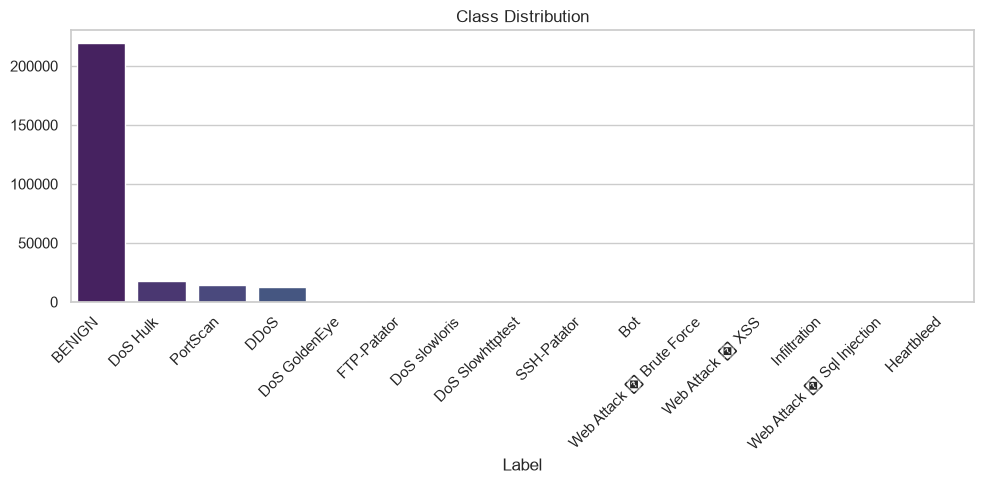

In [6]:
class_counts = df[LABEL_COL].value_counts()
display(class_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index,
            palette="viridis", legend=False)
plt.xticks(rotation=45, ha="right")
plt.title("Class Distribution")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_class_distribution.png"), dpi=150)
plt.show()


C:\Users\Sushant\AppData\Local\Temp\ipykernel_14836\662578867.py:4: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sushant\AppData\Local\Temp\ipykernel_14836\662578867.py:5: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig(os.path.join(PLOTS_DIR, "eda_class_imbalance_pie.png"), dpi=150)


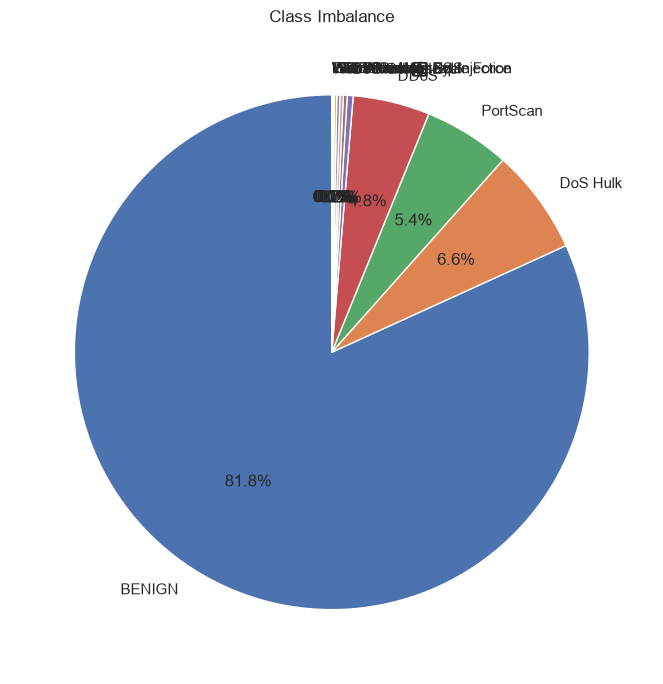

In [7]:
plt.figure(figsize=(7, 7))
plt.pie(class_counts.values, labels=class_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Class Imbalance")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_class_imbalance_pie.png"), dpi=150)
plt.show()


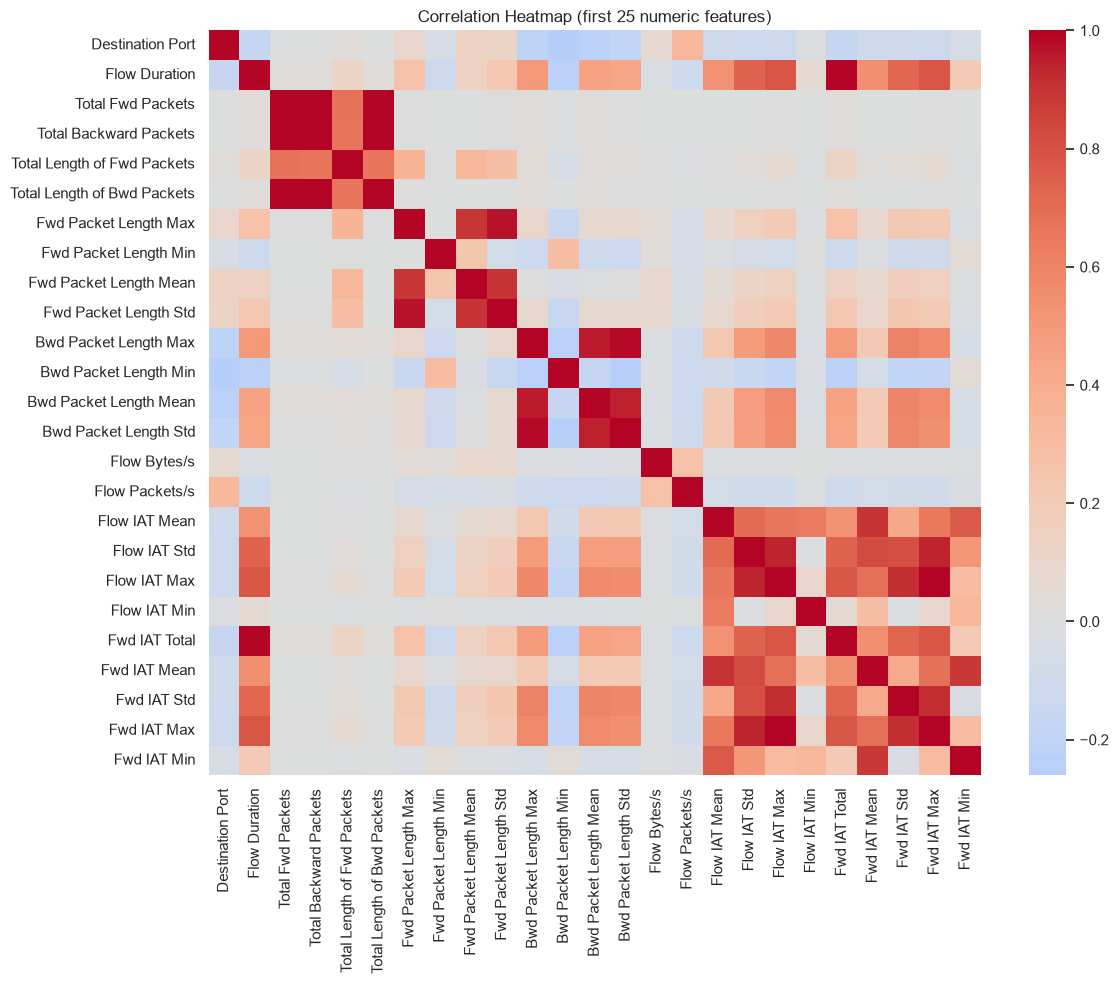

In [8]:
numeric_df = df.select_dtypes(include=[np.number])
corr_cols = numeric_df.columns[:25]
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df[corr_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (first 25 numeric features)")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_correlation_heatmap.png"), dpi=150)
plt.show()


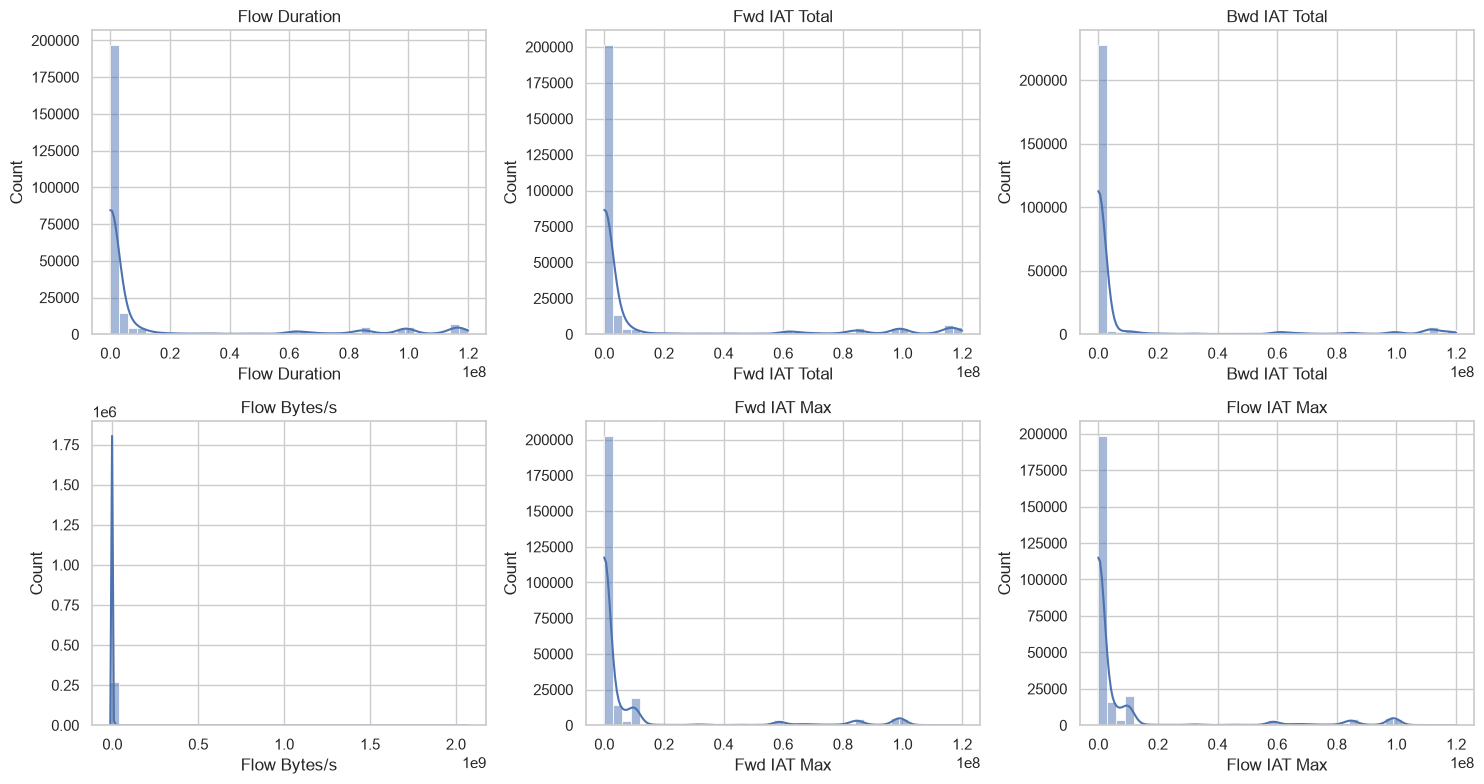

In [9]:
top_var_cols = numeric_df.var().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), top_var_cols):
    sns.histplot(numeric_df[col], bins=40, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "eda_histograms.png"), dpi=150)
plt.show()


## Label Encoding, Feature/Target Split

In [10]:
le = LabelEncoder()
df["Label_encoded"] = le.fit_transform(df[LABEL_COL])
class_names = le.classes_
n_classes = len(class_names)
print(f"{n_classes} classes:", list(class_names))

X = df.drop(columns=[LABEL_COL, "Label_encoded"]).select_dtypes(include=[np.number])
y = df["Label_encoded"].values
feature_names = X.columns.tolist()


15 classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


## Train/Test Split + Scaling (fit on train only)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.20, stratify=y, random_state=SEED
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Train: (214325, 78), Test: (53582, 78)


## SMOTE (training data only)

In [12]:
from collections import Counter

min_class_count = np.bincount(y_train).min()
k_neighbors = max(1, min(5, min_class_count - 1))

# Cap minority-class oversampling at 30% of the majority class size
# (instead of 100%), to keep the resampled dataset a manageable size
class_counts = Counter(y_train)
majority_count = max(class_counts.values())
target_ratio = 0.3
sampling_strategy_dict = {
    cls: max(count, int(majority_count * target_ratio))
    for cls, count in class_counts.items()
}

smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors, sampling_strategy=sampling_strategy_dict)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"Before SMOTE: {X_train.shape} -> After SMOTE: {X_train_res.shape}")

Before SMOTE: (214325, 78) -> After SMOTE: (911664, 78)


## Save Everything

Every downstream notebook (`01`–`07`) loads from `processed_data/`
instead of repeating any of the steps above.

In [13]:
np.save(os.path.join(PROCESSED_DIR, "X_train.npy"), X_train)             # pre-SMOTE, scaled (used by autoencoder)
np.save(os.path.join(PROCESSED_DIR, "X_train_res.npy"), X_train_res)     # SMOTE-resampled, scaled
np.save(os.path.join(PROCESSED_DIR, "y_train_res.npy"), y_train_res)
np.save(os.path.join(PROCESSED_DIR, "X_test.npy"), X_test)
np.save(os.path.join(PROCESSED_DIR, "y_test.npy"), y_test)

joblib.dump(scaler, os.path.join(PROCESSED_DIR, "scaler.joblib"))
joblib.dump(le, os.path.join(PROCESSED_DIR, "label_encoder.joblib"))
joblib.dump(feature_names, os.path.join(PROCESSED_DIR, "feature_names.joblib"))
joblib.dump(list(class_names), os.path.join(PROCESSED_DIR, "class_names.joblib"))
joblib.dump(n_classes, os.path.join(PROCESSED_DIR, "n_classes.joblib"))

print("Saved to", PROCESSED_DIR + "/:", sorted(os.listdir(PROCESSED_DIR)))


Saved to processed_data/: ['X_test.npy', 'X_train.npy', 'X_train_res.npy', 'class_names.joblib', 'feature_names.joblib', 'label_encoder.joblib', 'n_classes.joblib', 'scaler.joblib', 'y_test.npy', 'y_train_res.npy']
